# **K-Means Clustering from Scratch**

## 0.ライブラリのインポートとデータの生成

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(42)
X, y = make_blobs(n_samples=300, centers=3, cluster_std=4.5, random_state=42)

## 1.アルゴリズム

ラベルなしのデータをK個のクラスターに自動で分類する学習アルゴリズム。重心(セントロイド)を繰り返し更新することで、データの構造を発見する。

### 1.1.k-means

各データ点を最も近い重心（セントロイド）に割り当て、重心を繰り返し更新することで最適なクラスタリングを求める。

①K個の重心をデータからランダムに初期化

②各データ点を最も近い重心のクラスターに割り当て

③各クラスターの重心を再計算(クラスター内のデータ点の平均)

④重心が変化しなくなるまで2・3を繰り返す

### 1.2.エルボー法

最適なKを決めるための方法。各データ点から所属クラスターの重心までの距離の二乗和を慣性(inertia)と呼び、以下の式で表される。
$$\text{inertia} = \sum_{i=1}^{n} ||x_i - \mu_{c_i}||^2$$
Kを増やすほどinertiaは小さくなるが、ある数から減少が緩やかになる。その場所(elbow)でのKが最適なKとなる。

In [7]:
def euclidean_distance(x1, x2):
  return np.sqrt(np.sum((x1 - x2)**2))

def predict(X, centroids):
  distances = np.array([[euclidean_distance(x, centroid) for centroid in centroids] for x in X])
  return np.argmin(distances, axis=1)

def fit(X, k, max_iters=100):
  indices = np.random.choice(len(X), k, replace=False)
  centroids = X[indices]
  history = [centroids.copy()]

  for _ in range(max_iters):
    labels = predict(X, centroids)
    new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])

    if np.allclose(centroids, new_centroids):
      break
    centroids = new_centroids
    history.append(centroids.copy())

  return centroids, labels, history

## 2.モデルの可視化

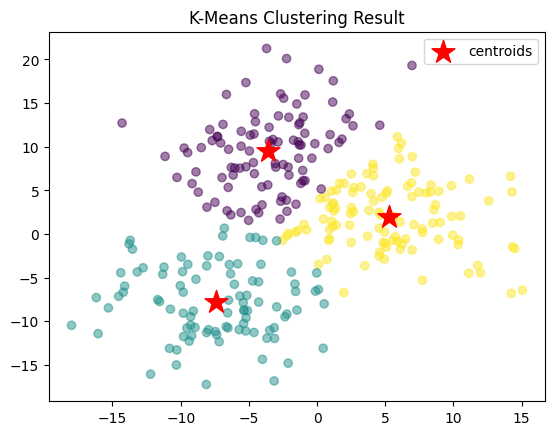

In [8]:
centroids, labels, history = fit(X, k=3)

plt.scatter(X[:, 0], X[:, 1], c=labels, alpha=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='*', s=300, label='centroids')
plt.title("K-Means Clustering Result")
plt.legend()
plt.show()

## 3.検証

### 3.1.エルボー法による検証

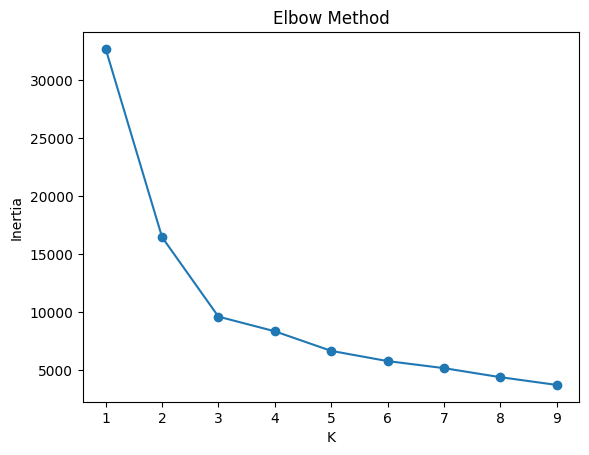

In [ ]:
inertias = []
k_values = range(1, 10)

for k in k_values:
  centroids_tmp, labels_tmp, _ = fit(X, k=k)
  inertia = sum([euclidean_distance(X[i], centroids_tmp[labels_tmp[i]])**2 for i in range(len(X))])
  inertias.append(inertia)

plt.plot(k_values, inertias, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### 3.2.収束過程

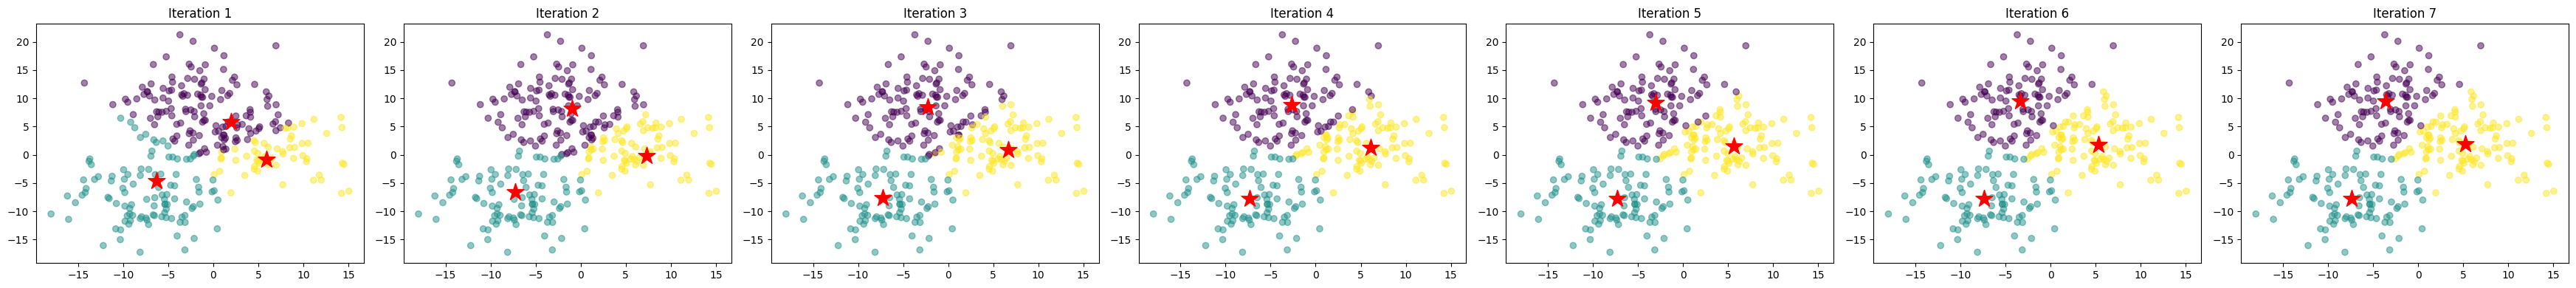

In [ ]:
fig, axes = plt.subplots(1, len(history), figsize=(5 * len(history), 4))
for i, cent in enumerate(history):
  axes[i].scatter(X[:, 0], X[:, 1], c=predict(X, cent), alpha=0.5)
  axes[i].scatter(cent[:, 0], cent[:, 1], c='red', marker='*', s=300)
  axes[i].set_title(f"Iteration {i+1}")
plt.tight_layout()
plt.show()